In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [2]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA')
from ESMCBA.imports import *
from ESMCBA import graph_utils

In [3]:
epitopes_eval = ['A3101',
 'B5701',
 'B1801',
 'A1101',
 'B4403',
 'B5101',
 'A2601',
 'B1501',
 'A3001',
 'A0205',
 'B3801',
 'A6801',
 'A0101',
 'B0702',
 'A0301',
 'A0201',
 'B4402',
 'B0801',
 'B3906',
 'B1402',
 'A2402',
 'B4001',
 'A3201',
 'B3501',
 'C0701']

In [4]:
# Build per-HLA counts, keep overlap peptides,
# AND collect BOTH training-set (≤2019) and testing-set (≥2020) epitopes per HLA

rows = []
overlap_peptides = {}     # {HLA: [peptide1, ...]}
eval_rows = []            # [{'HLA': hla, 'epitope': pep}, ...]
train_rows = []           # [{'HLA': hla, 'epitope': pep}, ...]

for file in glob.glob("/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLAHLA*_final.csv"):
    if 'HLAD' in file or os.stat(file).st_size == 0:
        continue

    df = pd.read_csv(file, sep=',', header=None)
    df.columns = ['sequence','ref_ID','submissionID','Epitope_ID','protein_origin',
                  'ID_SOURCE','SOURCE_ORGANISM','IC50_nM','DESCRIPTION_BINDING','Year_submission']

    # clean year and sequences
    df['Year_submission'] = pd.to_numeric(df['Year_submission'], errors='coerce')
    df = df[df['Year_submission'].notna() & (df['Year_submission'] > 0)]
    seq = df['sequence'].astype(str).str.strip().str.upper()

    # sets
    set1 = set(seq[df['Year_submission'] <= 2019].unique())  # training
    set2 = set(seq[df['Year_submission'] >  2019].unique())  # evaluation

    overlap = set1 & set2
    union   = set1 | set2

    hla = 'HLA' + os.path.basename(file).split('HLA')[-1].split('_final')[0]

    rows.append({
        'HLA': hla,
        'n_train_epitopes': len(set1),
        'n_eval_epitopes':  len(set2),
        'n_overlap':        len(overlap),
        'prop_overlap_train': (len(overlap)/len(set1)) if set1 else np.nan,
        'prop_overlap_eval':  (len(overlap)/len(set2)) if set2 else np.nan,
        'jaccard': (len(overlap)/len(union)) if union else np.nan,
        'n_union': len(union),
        'n_train_only': len(set1 - overlap),
        'n_eval_only':  len(set2 - overlap),
    })

    overlap_peptides[hla] = sorted(overlap)

    # collect per-HLA epitopes for train and eval
    if set1:
        train_rows.extend({'HLA': hla, 'epitope': pep} for pep in set1)
    if set2:
        eval_rows.extend({'HLA': hla, 'epitope': pep} for pep in set2)

# summary table per HLA
hla_counts = (pd.DataFrame(rows)
              .sort_values(['n_overlap','HLA'], ascending=[False, True])
              .reset_index(drop=True))

# long-form dataframes of epitopes by split
train_epitopes_df = (pd.DataFrame(train_rows)
                     .drop_duplicates(['HLA','epitope'])
                     .sort_values(['HLA','epitope'])
                     .reset_index(drop=True))

eval_epitopes_df = (pd.DataFrame(eval_rows)
                    .drop_duplicates(['HLA','epitope'])
                    .sort_values(['HLA','epitope'])
                    .reset_index(drop=True))

# optional combined table with a 'split' column
all_epitopes_df = pd.concat([
    train_epitopes_df.assign(split='train'),
    eval_epitopes_df.assign(split='eval')
], ignore_index=True)

# optional: explode the overlap list too
df_overlap = (pd.Series(overlap_peptides, name='epitope')
                .explode()
                .reset_index()
                .rename(columns={'index': 'HLA'})
                .dropna()
                .reset_index(drop=True))


In [5]:
hla_counts.to_csv('../../data/summary_BA_dataset.csv', index =None)

In [6]:
df_overlap = (
    pd.Series(overlap_peptides, name='peptide')
      .explode()
      .reset_index()
      .rename(columns={'index': 'file'})
)

# 2) keep only the basename and extract HLA from filename
df_overlap['file'] = df_overlap['file'].apply(os.path.basename)
df_overlap['HLA'] = df_overlap['file'].apply(
    lambda f: 'HLA' + f.split('HLA')[-1].split('_final')[0]
)

In [7]:
df_overlap['HLA'] = df_overlap['HLA'].str.replace('HLA','') #.str.replace('_final.csv','')
df_overlap.head(4)

,file,peptide,HLA
0,HLAB1509,NaN,B1509
1,HLAA3101,NaN,A3101
2,HLAA2301,NaN,A2301
3,HLAB4601,NaN,B4601


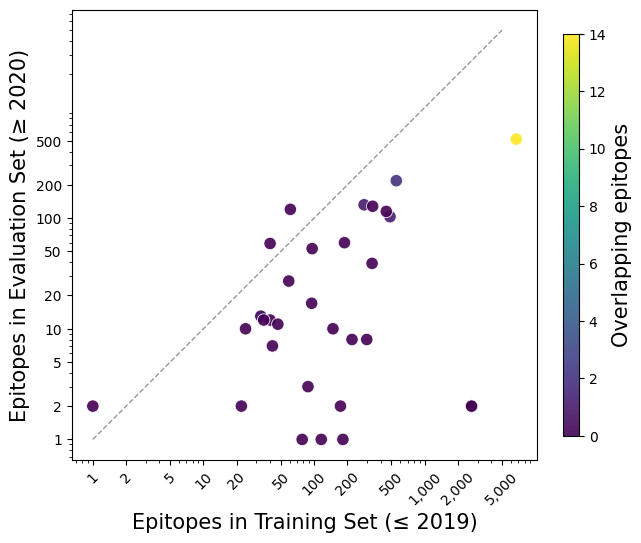

In [8]:
from matplotlib.colors import Normalize

df = hla_counts[(hla_counts['n_train_epitopes'] > 0) & (hla_counts['n_eval_epitopes'] > 0)].copy()

fig, ax = plt.subplots(figsize=(6.5, 6.5))

# 2) plot
sns.scatterplot(
    data=df,
    x='n_train_epitopes', y='n_eval_epitopes',
    hue='n_overlap', palette='viridis',hue_norm=(df['n_overlap'].min(), df['n_overlap'].max()), s=80, edgecolor='white', linewidth=0.6,
    alpha=0.9,  ax=ax, legend=False  # we'll use a colorbar instead
)

ax.set_xscale('log')
ax.set_yscale('log')

# 3) nice log ticks with real-number labels
def nice_log_ticks(vmin, vmax):
    vmin = max(vmin, 1)
    dmin = int(np.floor(np.log10(vmin)))
    dmax = int(np.ceil(np.log10(max(vmax, vmin))))
    ticks = []
    for d in range(dmin, dmax + 1):
        for m in (1, 2, 5):
            val = m * (10 ** d)
            if vmin <= val <= vmax:
                ticks.append(val)
    return np.unique(ticks)

xmin, xmax = df['n_train_epitopes'].min(), df['n_train_epitopes'].max()
ymin, ymax = df['n_eval_epitopes'].min(),  df['n_eval_epitopes'].max()

xticks = nice_log_ticks(xmin, xmax)
yticks = nice_log_ticks(ymin, ymax)

ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels([f"{int(t):,}" for t in xticks], rotation= 45, fontsize =10)
ax.set_yticklabels([f"{int(t):,}" for t in yticks], fontsize =10)

# 4) diagonal reference line (y = x)
lo = min(xticks[0], yticks[0])
hi = max(xticks[-1], yticks[-1])
ax.plot([lo, hi], [lo, hi], linestyle='--', linewidth=1, color='gray', alpha=0.8)

ax.collections[0].set_norm(Normalize(vmin=df['n_overlap'].min(), vmax=df['n_overlap'].max()))

# 5) colorbar for overlaps
mappable = ax.collections[0]
cbar = plt.colorbar(mappable, ax=ax, pad=0.05, fraction=0.035, shrink=0.7, aspect=25)

cbar.set_label('Overlapping epitopes', fontsize =15)

# 6) labels and cosmetics
ax.set_xlabel('Epitopes in Training Set (≤ 2019)', fontsize =15)
ax.set_ylabel('Epitopes in Evaluation Set (≥ 2020)', fontsize =15)
ax.set_aspect('equal', 'box')
ax.grid(False)
plt.tight_layout()


In [10]:
plot_data = pd.read_csv('../../data/01_predictions_models.csv')

In [12]:
def _norm_hla(h):
    s = str(h).upper().replace(' ', '').replace('*', '').replace(':', '').replace('-', '')
    return s if s.startswith('HLA') else 'HLA' + s

# HLA -> set of eval epitopes
eval_sets = (eval_epitopes_df
             .assign(HLA_norm=lambda d: d['HLA'].map(_norm_hla),
                     ep=lambda d: d['epitope'].astype(str).str.strip().str.upper())
             .groupby('HLA_norm')['ep']
             .apply(set))

train_sets = (train_epitopes_df
              .assign(HLA_norm=lambda d: d['HLA'].map(_norm_hla),
                      ep=lambda d: d['epitope'].astype(str).str.strip().str.upper())
              .groupby('HLA_norm')['ep']
              .apply(set))
              
# HLA -> set of sequences from plot_data
plot_sets = (plot_data
             .assign(HLA_norm=lambda d: d['level_0'].map(_norm_hla),
                     ep=lambda d: d['sequence'].astype(str).str.strip().str.upper())
             .groupby('HLA_norm')['ep']
             .apply(set))

common_hlas = eval_sets.index.intersection(plot_sets.index)

rows = []
overlap_long = []
for h in common_hlas:
    s_eval = eval_sets.loc[h]
    s_plot = plot_sets.loc[h]
    ov = s_eval & s_plot
    rows.append({
        'HLA': h,
        'n_eval': len(s_eval),
        'n_plot': len(s_plot),
        'n_overlap': len(ov)
    })
    overlap_long.extend({'HLA': h, 'epitope': p} for p in ov)

# summary per HLA
overlap_summary = (pd.DataFrame(rows)
                   .sort_values('n_overlap', ascending=False)
                   .reset_index(drop=True))

# one row per overlapping epitope
overlap_epitopes_df = (pd.DataFrame(overlap_long)
                       .sort_values(['HLA', 'epitope'])
                       .reset_index(drop=True))


# Use HLAs that appear in the plot data (so we only summarize HLAs we’re plotting)
hlas = plot_sets.index

rows = []
overlap_eval_long  = []
overlap_train_long = []

for h in hlas:
    s_plot  = plot_sets.loc[h] if h in plot_sets.index else set()
    s_eval  = eval_sets.loc[h] if h in eval_sets.index else set()
    s_train = train_sets.loc[h] if h in train_sets.index else set()

    ov_eval  = s_plot & s_eval
    ov_train = s_plot & s_train

    # unions for Jaccard with each split
    uni_eval  = s_plot | s_eval
    uni_train = s_plot | s_train

    rows.append({
        'HLA': h,
        'n_plot':  len(s_plot),
        'n_eval':  len(s_eval),
        'n_train': len(s_train),
        'n_overlap_eval':  len(ov_eval),
        'n_overlap_train': len(ov_train),
        'jaccard_eval':  (len(ov_eval)  / len(uni_eval))  if len(uni_eval)  else np.nan,
        'jaccard_train': (len(ov_train) / len(uni_train)) if len(uni_train) else np.nan,
 })

    overlap_eval_long.extend({'HLA': h, 'epitope': p, 'split': 'eval'}  for p in ov_eval)
    overlap_train_long.extend({'HLA': h, 'epitope': p, 'split': 'train'} for p in ov_train)

# Per-HLA summary including BOTH overlaps
overlap_summary_both = (pd.DataFrame(rows)
                        .sort_values(['n_overlap_eval','n_overlap_train','HLA'],
                                     ascending=[False, False, True])
                        .reset_index(drop=True))

# Long form of actual overlapping epitopes, split-labeled
overlap_epitopes_both_df = (pd.DataFrame(overlap_eval_long + overlap_train_long)
                            .sort_values(['HLA','split','epitope'])
                            .reset_index(drop=True))


In [13]:
overlap_train_long

[{'HLA': 'HLAA0201', 'epitope': 'YLVVVGAVGV', 'split': 'train'},
 {'HLA': 'HLAA0205', 'epitope': 'FPWDILFPS', 'split': 'train'},
 {'HLA': 'HLAA0205', 'epitope': 'QGFPWDILF', 'split': 'train'}]

In [14]:
plot_data = plot_data[~(plot_data['sequence'].isin(['YLVVVGAVGV', 'FPWDILFPS','QGFPWDILF']))]

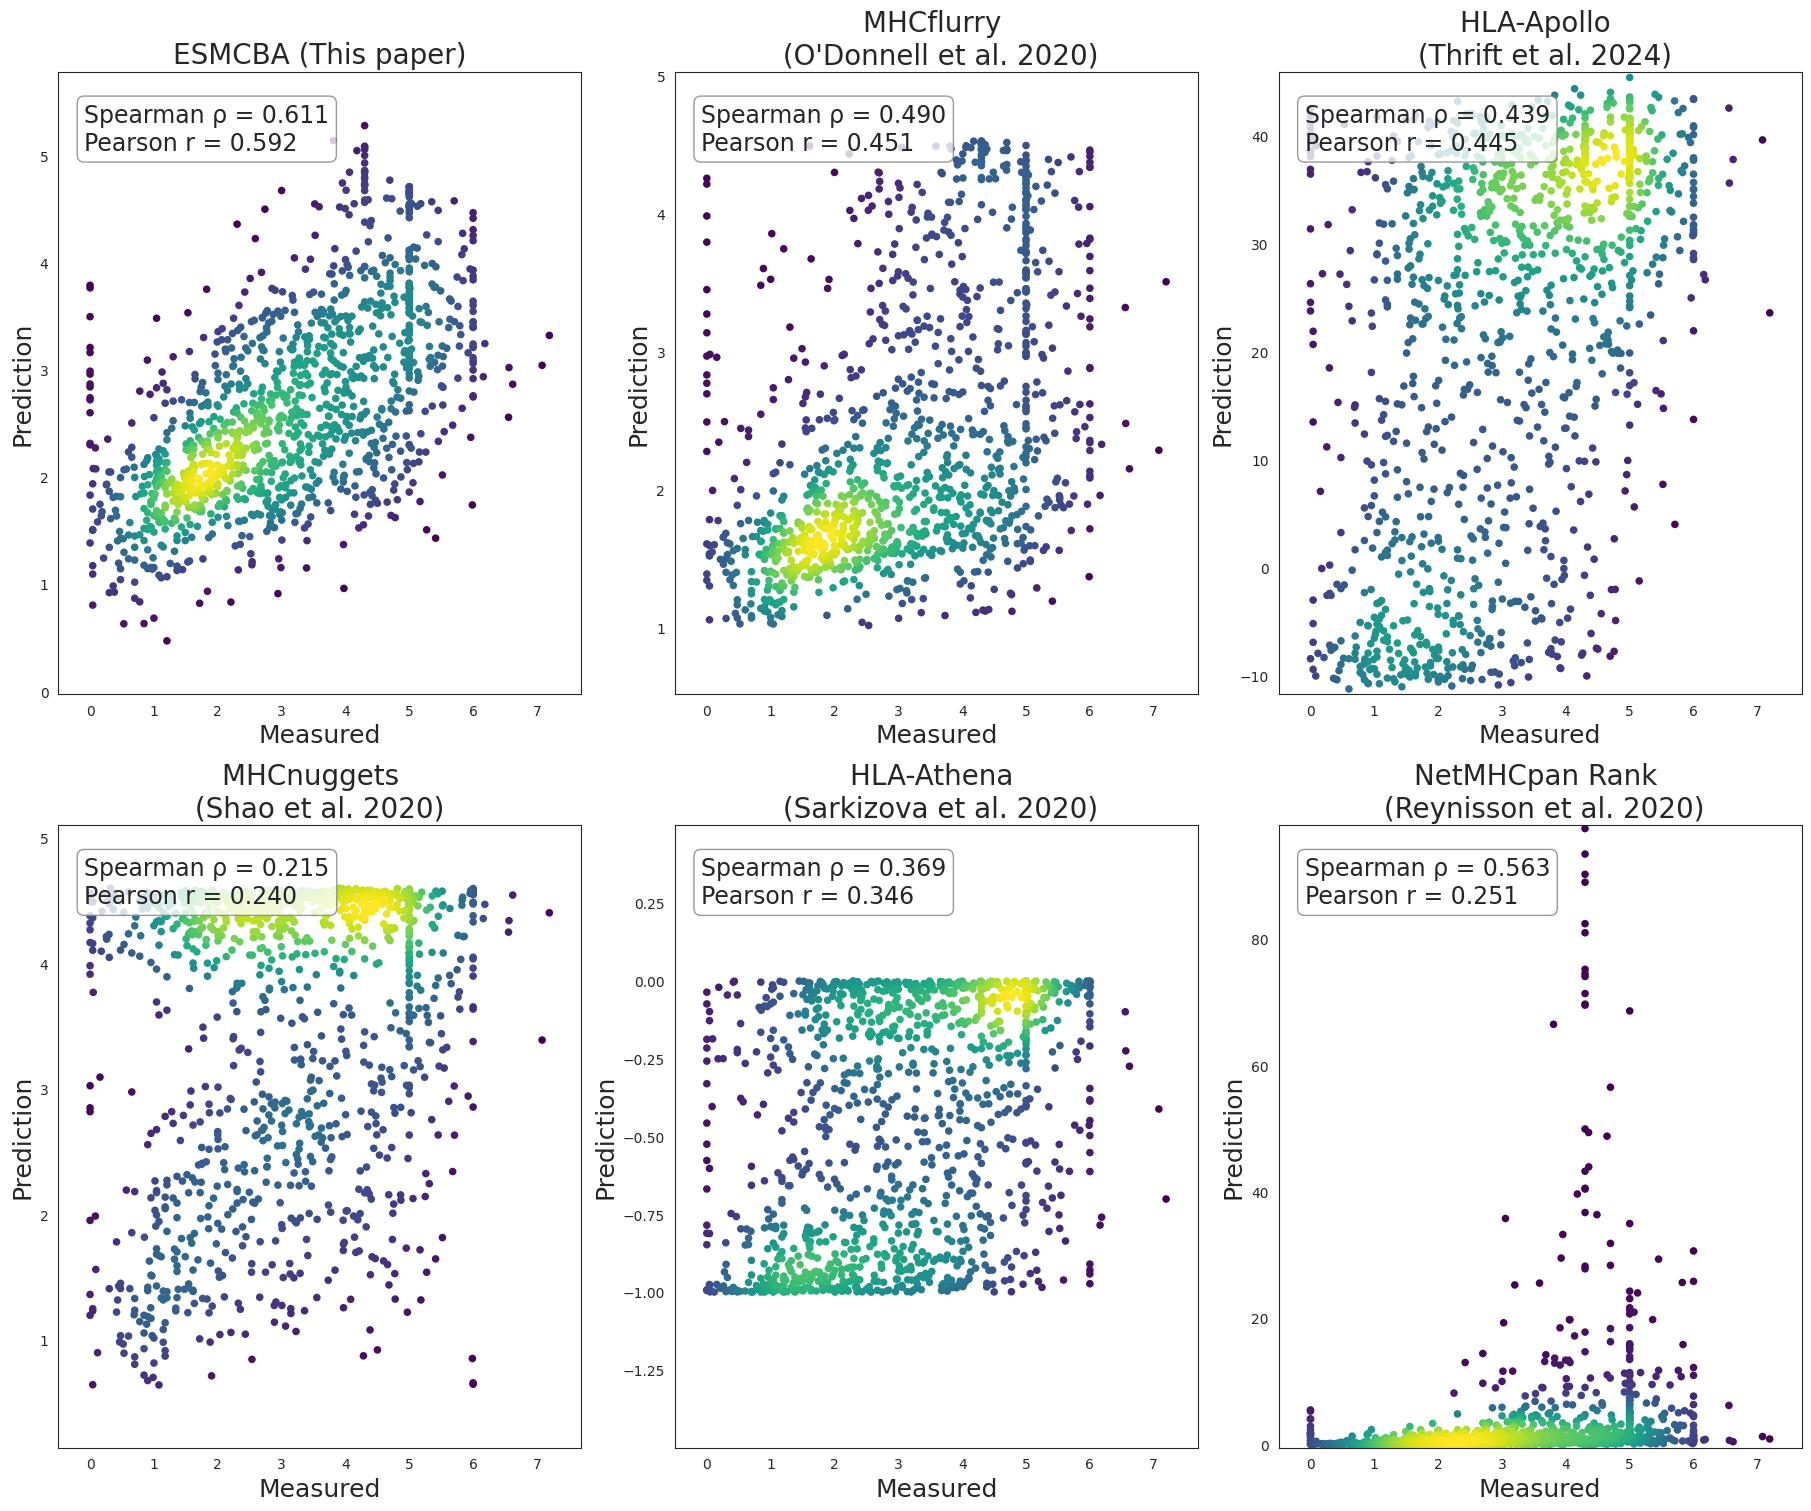

In [15]:
plot_pairs = [
    ('prediction', 'ESMCBA (This paper)'),
    ('mhc_log', "MHCflurry \n (O'Donnell et al. 2020)"),
    ('z_score_apollo', 'HLA-Apollo \n (Thrift et al. 2024)'),
    ('mhcnuggets_log', 'MHCnuggets  \n (Shao et al. 2020) '),
    ('best.MSi', 'HLA-Athena \n (Sarkizova et al. 2020)'),
    ('netmhc_log', 'NetMHCpan Rank \n (Reynisson et al. 2020)'),
    # ('mixmhc_rank', 'MixMHCpred (%Rank)'),
]


sns.set_style('white')

fig, axs = plt.subplots(2, 3, figsize=(18, 15), constrained_layout=True)
axs = axs.flatten()


for ax, (col, title) in zip(axs, plot_pairs):
    x = plot_data['measured']
    y = plot_data[col]

    # Drop NA
    valid = x.notna() & y.notna()
    x, y = x[valid], y[valid]

    # Density
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x.iloc[idx], y.iloc[idx], z[idx]

    # Plot
    sc = ax.scatter(x, y, c=z, cmap='viridis', s=30, edgecolor='none')
    spearman_rho, _ = spearmanr(x, y)
    pearson_r, _ = pearsonr(x, y)

    # Axis limits
    max_val = max(x.max(), y.max()) + 0.5
    ax.set_xlim(x.min()- 0.5, x.max() + 0.5)
    ax.set_ylim(y.min()- 0.5, y.max()+ 0.5)

    ax.set_title(title, fontsize=20)
    ax.set_xlabel('Measured', fontsize=18)
    ax.set_ylabel('Prediction', fontsize=18)
    
    # Correlation text with background box
    text_str = f'Spearman ρ = {spearman_rho:.3f}\nPearson r = {pearson_r:.3f}'
    ax.text(
        0.05, 0.95, text_str,
        transform=ax.transAxes,
        fontsize=17,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
    )

    for j in range(len(plot_pairs), len(axs)):
        axs[j].axis('off')

# from pathlib import Path
# out_dir = Path('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures_manuscript/')
# out_dir.mkdir(parents=True, exist_ok=True)
# fig.savefig(out_dir / "Scatterplot_models.pdf", dpi=300, bbox_inches="tight")
# plt.close(fig)

plt.show()
